# Milestone 1: Customer transaction fraud detection

This notebook explores the synthetic data, creates features from prior customer activity, and compares two baseline classifiers. Labels are synthetic and results are for learning only.

In [15]:
from pathlib import Path
import sys
ROOT = Path.cwd()
if ROOT.name == 'notebooks': ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, classification_report,
                             confusion_matrix, precision_recall_curve,
                             roc_auc_score)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from src.features.build_features import build_features

DATA_PATH = ROOT / 'data' / 'raw' / 'transactions.csv'
df = pd.read_csv(DATA_PATH, parse_dates=['timestamp'])
df.head()

,transaction_id,customer_id,amount,transaction_type,merchant_category,timestamp,location,device_id,beneficiary_id,is_fraud
0,TX0020322,C01017,852.35,atm,utilities,2025-01-01 06:00:00+00:00,Delhi,D01017-1,B01017-1,0
1,TX0020323,C01017,488.56,card,travel,2025-01-01 06:33:00+00:00,Delhi,D01017-1,B01017-1,0
2,TX0067841,C03393,1420.55,upi,cash,2025-01-01 06:37:00+00:00,Hyderabad,D03393-1,B03393-1,0
3,TX0038081,C01905,5288.87,bank_transfer,dining,2025-01-01 07:04:00+00:00,Chennai,D01905-1,B01905-1,0
4,TX0009461,C00474,2209.88,card,dining,2025-01-01 07:59:00+00:00,Pune,D00474-1,B00474-1,0


## Inspect the data and class balance

In [16]:
df.info()
df.describe(include='all').T.head(20)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype              
---  ------             --------------   -----              
 0   transaction_id     100000 non-null  object             
 1   customer_id        100000 non-null  object             
 2   amount             100000 non-null  float64            
 3   transaction_type   100000 non-null  object             
 4   merchant_category  100000 non-null  object             
 5   timestamp          100000 non-null  datetime64[ns, UTC]
 6   location           100000 non-null  object             
 7   device_id          100000 non-null  object             
 8   beneficiary_id     100000 non-null  object             
 9   is_fraud           100000 non-null  int64              
dtypes: datetime64[ns, UTC](1), float64(1), int64(1), object(7)
memory usage: 7.6+ MB


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
transaction_id,100000,100000,TX0020322,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_id,100000,5000,C01017,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN
amount,100000.0,NaN,NaN,NaN,9476.62764,100.0,1187.45,2823.76,6852.06,419127.22,28517.031284
transaction_type,100000,4,card,41987,NaN,NaN,NaN,NaN,NaN,NaN,NaN
merchant_category,100000,7,dining,14454,NaN,NaN,NaN,NaN,NaN,NaN,NaN
timestamp,100000,NaN,NaN,NaN,2025-02-07 23:11:30.487800320+00:00,2025-01-01 06:00:00+00:00,2025-01-24 12:26:00+00:00,2025-02-08 03:46:30+00:00,2025-02-22 11:09:00+00:00,2025-03-21 18:48:00+00:00,NaN
location,100000,6,Hyderabad,16954,NaN,NaN,NaN,NaN,NaN,NaN,NaN
device_id,100000,14343,D03754-1,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN
beneficiary_id,100000,16451,B00273-1,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_fraud,100000.0,NaN,NaN,NaN,0.04294,0.0,0.0,0.0,0.0,1.0,0.202723


Rows: 100000 Customers: 5000
Fraud rate: 4.29%
transaction_id       0
customer_id          0
amount               0
transaction_type     0
merchant_category    0
timestamp            0
location             0
device_id            0
beneficiary_id       0
is_fraud             0
dtype: int64


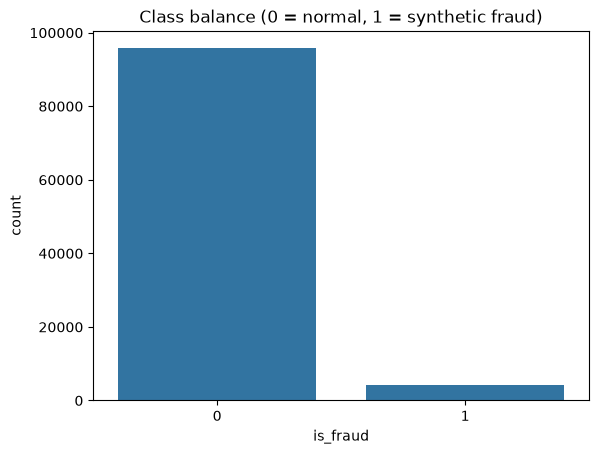

In [17]:
print('Rows:', len(df), 'Customers:', df.customer_id.nunique())
print('Fraud rate:', f"{df.is_fraud.mean():.2%}")
print(df.isna().sum())
sns.countplot(data=df, x='is_fraud')
plt.title('Class balance (0 = normal, 1 = synthetic fraud)')
plt.show()

## Create customer-history features

The feature function sorts each customer's events in time and uses prior transactions only. The label is excluded from feature construction. This prevents future behavior and the target from leaking into each row.

In [18]:
featured = build_features(df)
feature_cols = [
    'amount', 'amount_deviation', 'transactions_last_1h',
    'transactions_last_6h', 'transactions_last_24h',
    'new_beneficiary', 'new_device', 'location_deviation',
    'time_deviation_hours', 'transaction_type', 'merchant_category'
]
featured[feature_cols + ['is_fraud']].head()

,amount,amount_deviation,transactions_last_1h,transactions_last_6h,transactions_last_24h,new_beneficiary,new_device,location_deviation,time_deviation_hours,transaction_type,merchant_category,is_fraud
0,852.35,1.000000,0,0,0,0,0,0,0,atm,utilities,0
1,488.56,0.573192,1,1,1,0,0,0,0,card,travel,0
2,1420.55,1.000000,0,0,0,0,0,0,0,upi,cash,0
3,5288.87,1.000000,0,0,0,0,0,0,0,bank_transfer,dining,0
4,2209.88,1.000000,0,0,0,0,0,0,0,card,dining,0


## Chronological train/test split

Hold out the latest 20% of transaction timestamps to approximate scoring future activity. Keep transaction IDs and the target out of the model inputs.

In [19]:
featured = featured.sort_values('timestamp').reset_index(drop=True)
cut = int(len(featured) * 0.80)
train, test = featured.iloc[:cut], featured.iloc[cut:]
X_train, y_train = train[feature_cols], train['is_fraud']
X_test, y_test = test[feature_cols], test['is_fraud']
numeric = [c for c in feature_cols if c not in ['transaction_type', 'merchant_category']]
categorical = ['transaction_type', 'merchant_category']
preprocess = ColumnTransformer([
    ('numeric', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scale', StandardScaler())]), numeric),
    ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical),
])
print('Train:', len(train), 'Test:', len(test))
print('Train fraud rate:', y_train.mean(), 'Test fraud rate:', y_test.mean())

Train: 80000 Test: 20000
Train fraud rate: 0.0427375 Test fraud rate: 0.04375


## Fit baselines and compare fraud-focused metrics

Accuracy can look excellent when fraud is rare, even for a model that misses every fraud. Focus on precision, recall, F1, and especially PR-AUC. Thresholds are defaults here and should be chosen for the intended investigation workload.

In [20]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=250, min_samples_leaf=3,
        class_weight='balanced_subsample', random_state=42, n_jobs=-1),
}
results = {}
for name, estimator in models.items():
    pipe = Pipeline([('preprocess', preprocess), ('model', estimator)])
    pipe.fit(X_train, y_train)
    probabilities = pipe.predict_proba(X_test)[:, 1]
    predictions = (probabilities >= 0.5).astype(int)
    results[name] = {'pipeline': pipe, 'probabilities': probabilities, 'predictions': predictions,
                     'pr_auc': average_precision_score(y_test, probabilities)}
    print('\n', name)
    print('PR-AUC:', round(results[name]['pr_auc'], 4), 'ROC-AUC:', round(roc_auc_score(y_test, probabilities), 4))
    print(classification_report(y_test, predictions, zero_division=0))
    print('Confusion matrix [ [TN, FP], [FN, TP] ]:\n', confusion_matrix(y_test, predictions))


 Logistic Regression
PR-AUC: 0.5998 ROC-AUC: 0.9841
              precision    recall  f1-score   support

           0       1.00      0.97      0.98     19125
           1       0.58      1.00      0.74       875

    accuracy                           0.97     20000
   macro avg       0.79      0.98      0.86     20000
weighted avg       0.98      0.97      0.97     20000

Confusion matrix [ [TN, FP], [FN, TP] ]:
 [[18498   627]
 [    0   875]]

 Random Forest
PR-AUC: 0.5906 ROC-AUC: 0.9842
              precision    recall  f1-score   support

           0       1.00      0.97      0.98     19125
           1       0.59      1.00      0.74       875

    accuracy                           0.97     20000
   macro avg       0.79      0.98      0.86     20000
weighted avg       0.98      0.97      0.97     20000

Confusion matrix [ [TN, FP], [FN, TP] ]:
 [[18517   608]
 [    3   872]]


In [21]:
best_name = max(results, key=lambda name: results[name]['pr_auc'])
best_model = results[best_name]['pipeline']
print('Selected by PR-AUC:', best_name)
models_dir = ROOT / 'models'
models_dir.mkdir(exist_ok=True)
joblib.dump({'pipeline': best_model, 'feature_columns': feature_cols, 'model_name': best_name}, models_dir / 'fraud_model.joblib')
print('Saved to', models_dir / 'fraud_model.joblib')

Selected by PR-AUC: Logistic Regression
Saved to C:\Users\HARSH\Desktop\Python Project\models\fraud_model.joblib


## Notes and next steps

1. Compare precision and recall at several thresholds before choosing an alert threshold.
2. Inspect false positives and false negatives with customer history.
3. Try XGBoost only after understanding these baselines.
4. Add the separate prototype risk-band layer after model evaluation.

This generated dataset intentionally makes a share of fraud labels correlate with anomalies. Strong scores here do not imply production performance.

## Milestone 2: Transaction risk scoring

Keep the model signal separate from transparent behavior checks. The combined 0–100 score is an illustrative investigation-priority score, not a calibrated fraud probability or bank decision rule. The class-weighted model output is also not calibrated for real-world probabilities.

In [22]:
from src.risk.scoring import score_transactions

selected = results[best_name]
test_scores = score_transactions(selected["probabilities"], test[feature_cols])
risk_view = test[["transaction_id", "customer_id", "amount", "timestamp", "is_fraud"]].join(test_scores)

print("Selected model:", best_name)
print("⚠️ Model output is a prototype signal, not a calibrated real-bank fraud probability.")
display(risk_view.sort_values("transaction_risk_score", ascending=False).head(10))

Selected model: Logistic Regression
⚠️ Model output is a prototype signal, not a calibrated real-bank fraud probability.


,transaction_id,customer_id,amount,timestamp,is_fraud,model_probability,behavior_anomaly_score,transaction_risk_score,risk_level,risk_factors
84435,TX0052086,C02605,19468.61,2025-02-28 03:00:00+00:00,1,0.976404,0.8825,94.82,HIGH,"[Amount is 26.4x the customer's prior average,..."
87646,TX0039865,C01994,13762.36,2025-03-02 04:41:00+00:00,0,0.970645,0.8942,94.77,HIGH,"[Amount is 30.3x the customer's prior average,..."
89139,TX0020105,C01006,65677.82,2025-03-03 03:20:00+00:00,0,0.972315,0.8883,94.71,HIGH,"[Amount is 20.3x the customer's prior average,..."
84446,TX0082770,C04139,50529.19,2025-02-28 03:52:00+00:00,0,0.976003,0.8758,94.60,HIGH,"[Amount is 26.6x the customer's prior average,..."
87610,TX0006785,C00340,316531.57,2025-03-02 02:43:00+00:00,1,0.981091,0.8633,94.58,HIGH,"[Amount is 34.1x the customer's prior average,..."
91850,TX0077686,C03885,15357.41,2025-03-05 02:01:00+00:00,1,0.975508,0.8758,94.56,HIGH,"[Amount is 25.3x the customer's prior average,..."
82779,TX0064485,C03225,49518.30,2025-02-27 01:09:00+00:00,1,0.973055,0.8817,94.56,HIGH,"[Amount is 52.0x the customer's prior average,..."
82725,TX0008185,C00410,39418.70,2025-02-26 23:29:00+00:00,1,0.971391,0.8831,94.49,HIGH,"[Amount is 17.5x the customer's prior average,..."
90563,TX0070967,C03549,235805.36,2025-03-04 03:01:00+00:00,0,0.974470,0.8758,94.49,HIGH,"[Amount is 26.7x the customer's prior average,..."
89169,TX0095672,C04784,43489.14,2025-03-03 04:23:00+00:00,1,0.977559,0.8633,94.33,HIGH,"[Amount is 37.9x the customer's prior average,..."


### Risk bands and alert review

The HIGH/MEDIUM/LOW bands prioritize review for this prototype. Analysts should tune thresholds to their alert capacity and the costs of missed fraud versus false alarms.

In [23]:
band_summary = (risk_view.groupby("risk_level")
    .agg(transactions=("transaction_id", "count"), fraud_rate=("is_fraud", "mean"),
         average_score=("transaction_risk_score", "mean"))
    .reindex(["HIGH", "MEDIUM", "LOW"]))
display(band_summary)

sample_alert = risk_view.loc[risk_view.transaction_risk_score.idxmax()]
print(f"Transaction {sample_alert.transaction_id}: {sample_alert.risk_level} risk, "
      f"score {sample_alert.transaction_risk_score:.1f}/100")
print("Model signal:", f"{sample_alert.model_probability:.1%}")
print("Behavior anomaly score:", f"{sample_alert.behavior_anomaly_score:.1%}")
print("Reasons:")
for reason in sample_alert.risk_factors:
    print(" -", reason)

,transactions,fraud_rate,average_score
risk_level,,,
HIGH,1502.0,0.582557,88.915619
MEDIUM,NaN,NaN,NaN
LOW,18498.0,0.000000,1.090870


Transaction TX0052086: HIGH risk, score 94.8/100
Model signal: 97.6%
Behavior anomaly score: 88.2%
Reasons:
 - Amount is 26.4x the customer's prior average
 - Beneficiary has not appeared in this customer's prior transactions
 - Device has not appeared in this customer's prior transactions
 - Location has not appeared in this customer's prior transactions
 - Transaction time differs by 9 hours from prior activity


In [24]:
output_dir = ROOT / "data" / "processed"
output_dir.mkdir(parents=True, exist_ok=True)
risk_view.to_csv(output_dir / "test_risk_scores.csv", index=False)
print("Saved scored holdout transactions to", output_dir / "test_risk_scores.csv")

Saved scored holdout transactions to C:\Users\HARSH\Desktop\Python Project\data\processed\test_risk_scores.csv
